# Extension — does a transformer compress, and if so, *why*?

**This notebook goes beyond the paper.** It assumes
[`1_information_bottleneck.ipynb`](1_information_bottleneck.ipynb), whose estimator, dataset
and reasoning it reuses.

---

## The gap in the argument

Saxe et al.'s mechanism is stated in terms of the **activation function**: a compression
phase appears when a representation is squeezed through a *double-saturating* map and then
binned or noised. Their evidence covers tanh, sigmoid and softsign (which compress) versus
ReLU, softplus and linear (which do not).

Read naively, this says modern architectures should never compress — they are built from
ReLU-family nonlinearities. But a transformer block contains two operations the paper never
examined, and **both are bounded**:

| operation | why it is a saturating map |
|---|---|
| **softmax attention** | each output is a *convex combination* of value vectors, so it can never leave their convex hull; and the attention weights themselves saturate towards one-hot as the logits grow |
| **LayerNorm** | projects the residual stream onto a sphere of **fixed radius** $\sqrt{d}$ — however large the weights become, the representation cannot spread out |

A tanh unit compresses because growing weights push its output against a fixed ceiling.
LayerNorm imposes a fixed ceiling **by construction**, on every layer, whatever the
nonlinearity inside.

## The hypothesis

> By the paper's own mechanism, a transformer should show apparent compression driven by its
> **normalisation and attention**, not by its feed-forward nonlinearity. Concretely: a
> transformer with a **non-saturating** activation should compress **only when LayerNorm is
> present**, while a tanh transformer should compress either way — since tanh brings its own
> bound and needs no help.

That is falsifiable in several distinguishable ways, and it is what we test: a
$3 \times 2$ design, {GELU, ReLU, tanh} $\times$ {LayerNorm, no LayerNorm}, everything else
held fixed. For the MLPs of notebook 1 the *activation* axis was the whole story — tanh
10.66 bits, ReLU 0.47. Here we ask whether a second, architectural axis takes over.

## Design, and why it is built this way

* The input is the **same** 12-bit / 4096-pattern dataset as notebook 1, fed as a sequence
  of 12 binary tokens. Keeping the input space identical is deliberate: the 4096 patterns
  remain the *entire* input distribution, so binning-based mutual information stays
  **exact** and every number is directly comparable with notebook 1.
* $d_{\text{model}} = 8$, and every sequence-valued representation is **mean-pooled over
  positions**. A full $12 \times d$ representation would be so high-dimensional that all
  4096 inputs would land in separate bins, pinning $I(X;T)$ at $\log_2 4096 = 12$ bits with
  no dynamics — the machine-precision failure mode of notebook 1, §4.2.
* The model ends in a narrowing head ($8 \to 4 \to 2$), mirroring the Tishby architecture,
  so the deep representations are narrow enough for binning to resolve anything at all.

> **Runtime.** From an empty cache this notebook trains 6 transformers, about 18 minutes.
> Everything is cached to `final/cache/`, so later runs take seconds.

## 0. Setup

Same estimator and plotting helpers as notebook 1, repeated here so this notebook stands alone.

In [1]:
import gzip, math, pickle, time
from pathlib import Path

import numpy as np
import scipy.io as sio
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
import torch.nn as nn

ROOT = Path.cwd()
while not (ROOT / "reference" / "var_u.mat").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CACHE = ROOT / "final" / "cache";    CACHE.mkdir(parents=True, exist_ok=True)
FIGDIR = ROOT / "final" / "figures"; FIGDIR.mkdir(parents=True, exist_ok=True)

torch.set_num_threads(4)
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 180, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.grid": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8,
    "lines.linewidth": 1.6, "figure.facecolor": "white",
})

def cached(name, fn, force=False):
    path = CACHE / f"{name}.pkl.gz"
    if path.exists() and not force:
        with gzip.open(path, "rb") as fh:
            return pickle.load(fh)
    print(f"  computing '{name}' ...", flush=True)
    t0 = time.time()
    obj = fn()
    with gzip.open(path, "wb", compresslevel=4) as fh:
        pickle.dump(obj, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"  done in {time.time() - t0:.0f}s", flush=True)
    return obj

def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png")
    fig.savefig(FIGDIR / f"{name}.pdf")

# ---- the same binning estimator as notebook 1, repeated so this notebook stands alone --
def entropy_of_rows(codes):
    codes = np.ascontiguousarray(codes)
    if codes.ndim == 1:
        codes = codes[:, None]
    _, inverse = np.unique(codes, axis=0, return_inverse=True)
    counts = np.bincount(inverse.ravel())
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log2(p)).sum())

def mi_binned(h, y, n_bins=30, bounds=(-1.0, 1.0)):
    """(I(X;T), I(T;Y)) in bits.  I(X;T) = H(T) because T = bin(f(X)) is
    deterministic in X and the P rows enumerate the whole input distribution."""
    edges = np.linspace(bounds[0], bounds[1], n_bins + 1)
    T = np.digitize(np.asarray(h, dtype=np.float64), edges[1:-1]).astype(np.int32)
    H_T = entropy_of_rows(T)
    H_T_given_Y = sum((y == c).mean() * entropy_of_rows(T[y == c]) for c in np.unique(y))
    return H_T, H_T - H_T_given_Y

def information_plane(acts_per_checkpoint, y, **kw):
    ixt, ity = [], []
    for acts in acts_per_checkpoint:
        pairs = [mi_binned(a, y, **kw) for a in acts]
        ixt.append([p[0] for p in pairs])
        ity.append([p[1] for p in pairs])
    return np.array(ixt), np.array(ity)

def plot_plane(epochs, I_XT, I_TY, ax=None, title="", layer_names=None, colorbar=True):
    I_XT, I_TY, epochs = np.asarray(I_XT), np.asarray(I_TY), np.asarray(epochs)
    if ax is None:
        _, ax = plt.subplots(figsize=(4.6, 3.8))
    e = np.where(epochs == 0, 1, epochs)
    norm_ = LogNorm(vmin=max(e.min(), 1), vmax=e.max())
    sm = plt.cm.ScalarMappable(norm=norm_, cmap="viridis")
    step = max(1, len(epochs) // 25)
    for i in range(0, len(epochs), step):
        ax.plot(I_XT[i], I_TY[i], "-", color=sm.to_rgba(e[i]), alpha=0.35, lw=0.5, zorder=1)
    for j in range(I_XT.shape[1]):
        ax.scatter(I_XT[:, j], I_TY[:, j], c=e, cmap="viridis", norm=norm_, s=20,
                   edgecolors="none", zorder=2)
    ax.set_xlabel(r"$I(X;T)$  [bits]"); ax.set_ylabel(r"$I(T;Y)$  [bits]")
    ax.set_title(title)
    if colorbar:
        cb = ax.figure.colorbar(sm, ax=ax, pad=0.02)
        cb.set_label("epoch", fontsize=8); cb.ax.tick_params(labelsize=7)
    return ax

def load_tishby(train_fraction=0.8, seed=0):
    mat = sio.loadmat(str(ROOT / "reference" / "var_u.mat"))
    X = mat["F"].astype(np.float32)
    y = np.squeeze(mat["y"]).astype(np.int64)
    Y = np.eye(2, dtype=np.float32)[y]
    idx = np.random.default_rng(seed).permutation(len(X))
    n = int(round(train_fraction * len(X)))
    return (X[idx[:n]], Y[idx[:n]]), (X[idx[n:]], Y[idx[n:]]), (X, y)

print("project root :", ROOT)
print("torch", torch.__version__)

project root : /home/hooman/Desktop/InfoTheory/Project
torch 2.13.0+cpu


---

# 1. The model

A standard pre-norm transformer block, small enough to read in full. Note the two lines
marked `BOUNDED` — they are the entire subject of this notebook.

$$\begin{aligned}
x &\leftarrow x + \mathrm{Attn}(\mathrm{LN}_1(x)) \\
x &\leftarrow x + W_2\,\sigma\big(W_1\,\mathrm{LN}_2(x)\big)
\end{aligned}$$

Setting `layernorm=False` replaces both $\mathrm{LN}$s with the identity and changes nothing
else — that is the experimental knob.

In [2]:
ACTIVATIONS = {"gelu": nn.functional.gelu, "relu": torch.relu, "tanh": torch.tanh}


class SelfAttention(nn.Module):
    """Multi-head self-attention that also returns its attention weights.

    The weights matter to us for their own sake: as attention sharpens towards
    one-hot it saturates, in exactly the sense that drives compression in the
    paper's tanh networks.
    """

    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads, self.d_head = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        shape = (B, T, self.n_heads, self.d_head)
        q, k, v = (t.view(shape).transpose(1, 2) for t in (q, k, v))
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        attn = torch.softmax(scores, dim=-1)      # BOUNDED: rows lie on the simplex
        out = (attn @ v).transpose(1, 2).reshape(B, T, D)
        return self.proj(out), attn


class Block(nn.Module):
    """Standard pre-norm transformer block, with LayerNorm switchable off."""

    def __init__(self, d_model, n_heads, d_ff, activation, layernorm):
        super().__init__()
        # BOUNDED: LayerNorm projects the stream onto a sphere of radius sqrt(d)
        self.ln1 = nn.LayerNorm(d_model) if layernorm else nn.Identity()
        self.ln2 = nn.LayerNorm(d_model) if layernorm else nn.Identity()
        self.attn = SelfAttention(d_model, n_heads)
        self.ff1 = nn.Linear(d_model, d_ff)
        self.ff2 = nn.Linear(d_ff, d_model)
        self.act = ACTIVATIONS[activation]

    def forward(self, x):
        a, attn = self.attn(self.ln1(x))
        x = x + a                                  # residual
        h_ff = self.act(self.ff1(self.ln2(x)))
        x = x + self.ff2(h_ff)
        return x, {"attn": attn, "attn_out": a, "ff_hidden": h_ff, "residual": x}


class TinyTransformer(nn.Module):
    """Encoder-only transformer over 12 binary tokens, with a narrowing head.

    forward_with_acts returns the tracked representations.  Everything
    sequence-valued is MEAN-POOLED over positions: a full 12 x d representation
    would be so high-dimensional that all 4096 inputs land in separate bins and
    I(X;T) sits pinned at log2(4096) = 12 bits with no dynamics -- the
    machine-precision failure mode of the paper's appendix C.
    """

    def __init__(self, activation="gelu", layernorm=True, n_layers=2, d_model=8,
                 n_heads=2, d_ff=16, head_hidden=(4,), n_tokens=12, vocab=2, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.cfg = dict(activation=activation, layernorm=layernorm, n_layers=n_layers,
                        d_model=d_model, n_heads=n_heads, d_ff=d_ff)
        self.tok_emb = nn.Embedding(vocab, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(n_tokens, d_model))
        nn.init.normal_(self.tok_emb.weight, std=0.5)
        nn.init.normal_(self.pos_emb, std=0.5)

        self.blocks = nn.ModuleList(
            Block(d_model, n_heads, d_ff, activation, layernorm) for _ in range(n_layers))
        self.ln_f = nn.LayerNorm(d_model) if layernorm else nn.Identity()

        sizes = [d_model, *head_hidden]
        self.head = nn.ModuleList(nn.Linear(a, b) for a, b in zip(sizes[:-1], sizes[1:]))
        self.out = nn.Linear(sizes[-1], 2)
        self.act = ACTIVATIONS[activation]

        self.layer_names = ["embed"]
        for i in range(n_layers):
            self.layer_names += [f"B{i+1} attn", f"B{i+1} ff", f"B{i+1} resid"]
        self.layer_names += ["pooled"] + [f"head{i+1}" for i in range(len(self.head))] + ["out"]

    def forward_with_acts(self, x):
        h = self.tok_emb(x.long()) + self.pos_emb        # (B, T, d)
        acts = [h.mean(1)]
        for block in self.blocks:
            h, info = block(h)
            acts += [info["attn_out"].mean(1), info["ff_hidden"].mean(1),
                     info["residual"].mean(1)]
        z = self.ln_f(h).mean(1)
        acts.append(z)
        for lin in self.head:
            z = self.act(lin(z))
            acts.append(z)
        logits = self.out(z)
        acts.append(torch.sigmoid(logits))
        return logits, acts

    def forward(self, x):
        return self.forward_with_acts(x)[0]

    @torch.no_grad()
    def attention_entropy(self, x):
        """Mean entropy (bits) of the attention distributions, per block.

        Uniform attention over 12 positions = log2(12) = 3.58 bits; a fully
        sharpened one-hot pattern = 0.  Falling entropy means attention is
        saturating -- the transformer's analogue of a tanh unit going flat.
        """
        h = self.tok_emb(x.long()) + self.pos_emb
        out = []
        for block in self.blocks:
            h, info = block(h)
            a = info["attn"].clamp_min(1e-12)
            out.append(float((-(a * a.log2()).sum(-1)).mean()))
        return np.array(out)

    @torch.no_grad()
    def residual_norms(self, x):
        """Mean L2 norm of the residual stream after each block."""
        h = self.tok_emb(x.long()) + self.pos_emb
        out = []
        for block in self.blocks:
            h, _ = block(h)
            out.append(float(h.norm(dim=-1).mean()))
        return np.array(out)


def log_spaced(n_epochs, n_points=50, n_dense=20):
    dense = np.arange(0, min(n_dense, n_epochs) + 1)
    if n_epochs <= n_dense:
        return dense
    sparse = np.geomspace(max(n_dense, 1), n_epochs, n_points).round().astype(int)
    return np.unique(np.concatenate([dense, sparse, [n_epochs]]))


def train_transformer(activation="gelu", layernorm=True, lr=0.01, batch_size=256,
                      n_epochs=2000, n_checkpoints=50, seed=0):
    (Xtr, Ytr), (Xte, Yte), (Xall, _) = load_tishby(seed=seed)
    net = TinyTransformer(activation=activation, layernorm=layernorm, seed=seed)
    Xtr_t, Ytr_t = torch.from_numpy(Xtr), torch.from_numpy(Ytr)
    Xte_t, Yte_t = torch.from_numpy(Xte), torch.from_numpy(Yte)
    Xall_t = torch.from_numpy(Xall)

    P = len(Xtr)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    gen = torch.Generator().manual_seed(seed)
    loss_fn = nn.functional.binary_cross_entropy_with_logits
    ckpts = {int(c) for c in log_spaced(n_epochs, n_checkpoints)}

    out = {"epochs": [], "activations": [], "train_acc": [], "test_acc": [],
           "attn_entropy": [], "residual_norm": [], "weight_norm": [],
           "layer_names": net.layer_names, "activation": activation, "layernorm": layernorm}

    @torch.no_grad()
    def record(ep):
        net.eval()
        _, acts = net.forward_with_acts(Xall_t)
        out["activations"].append([a.numpy().copy() for a in acts])
        out["train_acc"].append(float((net(Xtr_t).argmax(-1) == Ytr_t.argmax(-1)).float().mean()))
        out["test_acc"].append(float((net(Xte_t).argmax(-1) == Yte_t.argmax(-1)).float().mean()))
        out["attn_entropy"].append(net.attention_entropy(Xall_t))
        out["residual_norm"].append(net.residual_norms(Xall_t))
        out["weight_norm"].append(float(sum(p.detach().norm()**2 for n_, p in
                                            net.named_parameters() if p.dim() >= 2) ** 0.5))
        out["epochs"].append(ep)
        net.train()

    record(0)
    for ep in range(1, n_epochs + 1):
        perm = torch.randperm(P, generator=gen)
        for s in range(0, P, batch_size):
            idx = perm[s:s + batch_size]
            opt.zero_grad(set_to_none=True)
            loss_fn(net(Xtr_t[idx]), Ytr_t[idx]).backward()
            opt.step()
        if ep in ckpts:
            record(ep)

    for k in ("epochs", "train_acc", "test_acc", "attn_entropy", "residual_norm", "weight_norm"):
        out[k] = np.array(out[k])
    return out

In [3]:
demo = TinyTransformer()
n_params = sum(p.numel() for p in demo.parameters())
print(f"architecture     : 2 blocks, d_model=8, 2 heads, d_ff=16, head 8 -> 4 -> 2")
print(f"parameters       : {n_params}")
print(f"tracked reps ({len(demo.layer_names)}) : {demo.layer_names}")
print()
print("'B1 ff' is the feed-forward hidden activation -- the only place the ACTIVATION")
print("FUNCTION acts. 'B1 resid' is the residual stream. 'pooled' is after the final LN.")

architecture     : 2 blocks, d_model=8, 2 heads, d_ff=16, head 8 -> 4 -> 2
parameters       : 1310
tracked reps (10) : ['embed', 'B1 attn', 'B1 ff', 'B1 resid', 'B2 attn', 'B2 ff', 'B2 resid', 'pooled', 'head1', 'out']

'B1 ff' is the feed-forward hidden activation -- the only place the ACTIVATION
FUNCTION acts. 'B1 resid' is the residual stream. 'pooled' is after the final LN.


## 1.1 Train the six configurations

In [4]:
ACTS = ["gelu", "relu", "tanh"]
LN = [True, False]

logs = {}
for a in ACTS:
    for ln in LN:
        tag = f"tf_{a}_{'ln' if ln else 'noln'}"
        logs[(a, ln)] = cached(tag, lambda a=a, ln=ln: train_transformer(activation=a, layernorm=ln))

print(f"{'activation':10s} {'LayerNorm':>10s} {'train acc':>10s} {'test acc':>9s}")
print("-" * 43)
for (a, ln), lg in logs.items():
    print(f"{a:10s} {str(ln):>10s} {lg['train_acc'][-1]:>10.3f} {lg['test_acc'][-1]:>9.3f}")
print()
print("All six learn the task, so any difference in the information plane is not a")
print("difference in how well they learned.")

activation  LayerNorm  train acc  test acc
-------------------------------------------
gelu             True      1.000     0.983
gelu            False      1.000     0.969
relu             True      1.000     0.979
relu            False      1.000     0.972
tanh             True      1.000     0.983
tanh            False      1.000     0.987

All six learn the task, so any difference in the information plane is not a
difference in how well they learned.


---

# 2. Are the bounded operations actually saturating?

Before asking about information, check the premise with two direct measurements:

* **attention entropy** — the entropy of each attention distribution over the 12 positions.
  Uniform attention gives $\log_2 12 = 3.58$ bits; fully sharpened one-hot attention gives
  $0$. Falling entropy means attention is saturating.
* **residual-stream norm** — with LayerNorm the normalised stream is pinned to radius
  $\sqrt{d}$; without it the stream is free to grow without limit.

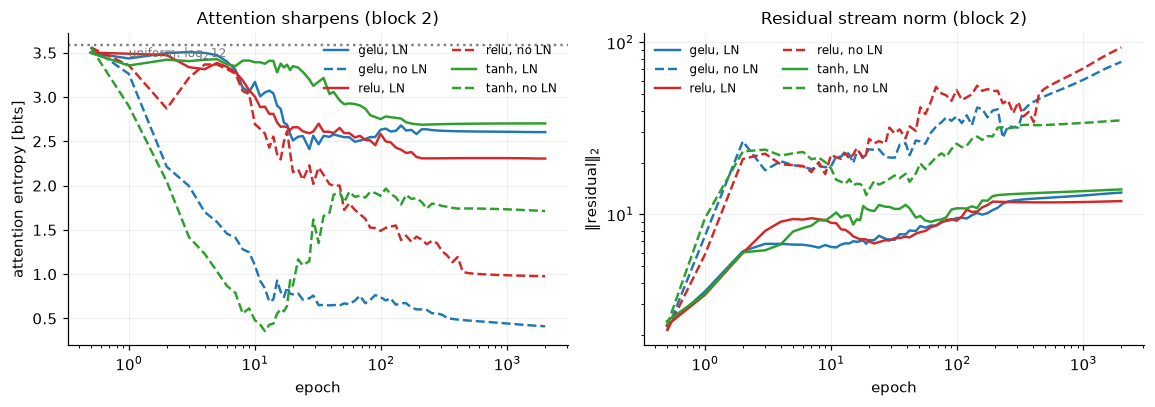

config                    attention entropy              residual norm
                        start -> end [bits]               start -> end
----------------------------------------------------------------------
gelu, LN                3.50 -> 2.60                2.26 -> 13.41       
gelu, no LN             3.56 -> 0.41                2.11 -> 77.14       
relu, LN                3.50 -> 2.31                2.26 -> 11.96       
relu, no LN             3.56 -> 0.98                2.10 -> 93.68       
tanh, LN                3.50 -> 2.70                2.39 -> 13.98       
tanh, no LN             3.56 -> 1.71                2.26 -> 35.27       


In [5]:
colors = {"gelu": "#1f77b4", "relu": "#d62728", "tanh": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.8))
for (a, ln), lg in logs.items():
    x = np.maximum(lg["epochs"], 0.5)
    axes[0].plot(x, lg["attn_entropy"][:, -1], color=colors[a], ls="-" if ln else "--",
                 label=f"{a}, {'LN' if ln else 'no LN'}")
    axes[1].plot(x, lg["residual_norm"][:, -1], color=colors[a], ls="-" if ln else "--",
                 label=f"{a}, {'LN' if ln else 'no LN'}")
axes[0].axhline(np.log2(12), ls=":", color="0.5")
axes[0].text(1, np.log2(12) * 0.96, r"uniform: $\log_2 12$", fontsize=8, color="0.45")
axes[0].set_xscale("log"); axes[0].set_xlabel("epoch")
axes[0].set_ylabel("attention entropy [bits]")
axes[0].set_title("Attention sharpens (block 2)"); axes[0].legend(ncol=2)
axes[1].set_xscale("log"); axes[1].set_yscale("log"); axes[1].set_xlabel("epoch")
axes[1].set_ylabel(r"$\|$residual$\|_2$")
axes[1].set_title("Residual stream norm (block 2)"); axes[1].legend(ncol=2)
fig.tight_layout(); save(fig, "figT1_saturation_diagnostics"); plt.show()

print(f"{'config':16s} {'attention entropy':>26s} {'residual norm':>26s}")
print(f"{'':16s} {'start -> end [bits]':>26s} {'start -> end':>26s}")
print("-" * 70)
for (a, ln), lg in logs.items():
    e, r = lg["attn_entropy"][:, -1], lg["residual_norm"][:, -1]
    print(f"{a + ', ' + ('LN' if ln else 'no LN'):16s} "
          f"{e[0]:>11.2f} -> {e[-1]:<12.2f} {r[0]:>11.2f} -> {r[-1]:<12.2f}")

Both premises hold, and the second one already contains a surprise worth remembering for
§5: **removing LayerNorm makes attention saturate far *harder*** (entropy collapses towards
one-hot), while the residual norm explodes.

---

# 3. The information plane

Binning over all 4096 patterns, so $I(X;T) = H(T)$ exactly, as in notebook 1. Following the
paper's appendix-C protocol for unbounded activations, the bin range for each run is set
from the extreme activities that run ever produced.

In [6]:
_, _, (X_all, y_all) = load_tishby()

def plane_of(lg, n_bins=30):
    lo = min(float(a.min()) for acts in lg["activations"] for a in acts)
    hi = max(float(a.max()) for acts in lg["activations"] for a in acts)
    return information_plane(lg["activations"], y_all, n_bins=n_bins, bounds=(lo, hi))

planes = {k: cached(f"plane_tf_{k[0]}_{'ln' if k[1] else 'noln'}", lambda k=k: plane_of(logs[k]))
          for k in logs}
print("computed", len(planes), "information planes")

computed 6 information planes


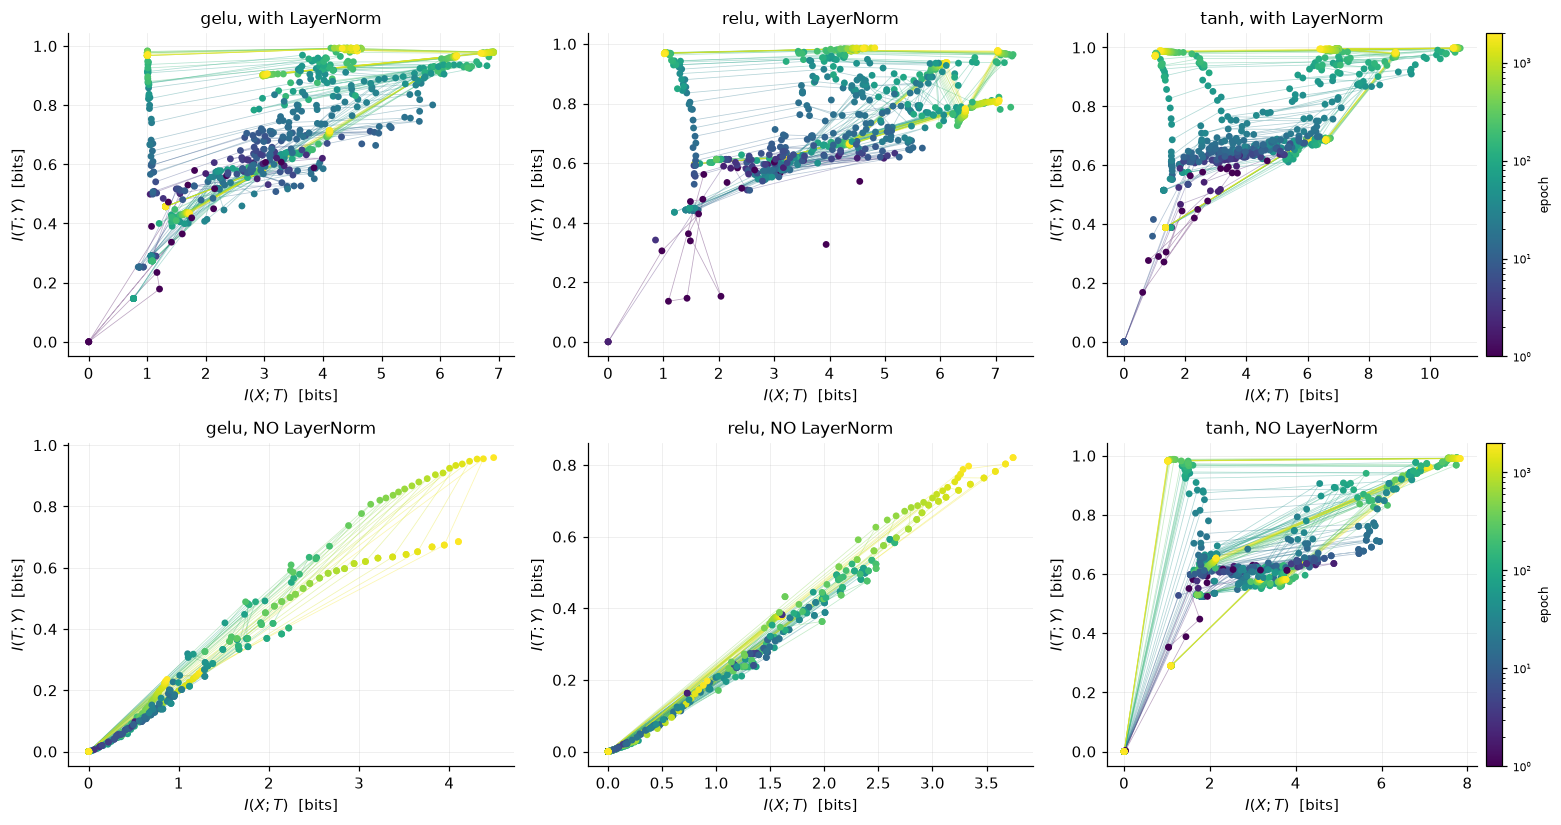

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14.4, 7.6))
for col, a in enumerate(ACTS):
    for row, ln in enumerate(LN):
        ixt, ity = planes[(a, ln)]
        plot_plane(logs[(a, ln)]["epochs"], ixt, ity, ax=axes[row, col],
                   title=f"{a}, {'with LayerNorm' if ln else 'NO LayerNorm'}",
                   colorbar=(col == 2))
fig.tight_layout(); save(fig, "figT2_transformer_planes"); plt.show()

---

# 4. The test

The hypothesis makes one sharp, falsifiable prediction, and it concerns the two
**non-saturating** activations. By the paper's mechanism, GELU and ReLU networks should not
compress at all. So:

> If LayerNorm is doing the work, then **GELU and ReLU should compress with LayerNorm and
> not without it**, while **tanh should compress either way** — because tanh brings its own
> boundedness and does not need to be handed any.

That is a prediction about the *pattern* of the $3 \times 2$ table, not just about which
main effect is larger, and it can fail in several distinguishable ways.

In [8]:
comp = {k: (p[0].max(0) - p[0][-1]) for k, p in planes.items()}

print("total compression across all tracked representations [bits]")
print(f"{'':12s} {'with LN':>10s} {'no LN':>10s} {'LN effect':>11s}   saturating?")
print("-" * 58)
for a in ACTS:
    with_ln, without = comp[(a, True)].sum(), comp[(a, False)].sum()
    sat = "yes (double)" if a == "tanh" else "no"
    print(f"{a:12s} {with_ln:>10.2f} {without:>10.2f} {with_ln - without:>+11.2f}   {sat}")

NON_SAT = ["gelu", "relu"]
worst_ln = min(comp[(a, True)].sum() for a in NON_SAT)      # weakest WITH LayerNorm
best_no  = max(comp[(a, False)].sum() for a in NON_SAT)     # strongest WITHOUT it
tanh_no  = comp[("tanh", False)].sum()
print()
print(f"non-saturating activations, WITHOUT LayerNorm : at most {best_no:.2f} bits")
print(f"non-saturating activations, WITH LayerNorm    : at least {worst_ln:.2f} bits")
print(f"tanh without LayerNorm (the control)          : {tanh_no:.2f} bits")
print()
if best_no < 0.5 and worst_ln > 1.0 and tanh_no > 1.0:
    print("=> Every part of the prediction holds.")
    print("   A transformer whose only nonlinearity is ReLU-family shows NO compression at")
    print("   all -- until a LayerNorm is added, at which point it compresses several bits.")
    print("   tanh compresses either way, since it supplies its own bound.")
    print("   Compression here is created by NORMALISATION, an operation the paper never")
    print("   examined, and one that is present in essentially every real transformer.")
else:
    print("=> The prediction does not hold in this form; read the table above directly.")

total compression across all tracked representations [bits]
                with LN      no LN   LN effect   saturating?
----------------------------------------------------------
gelu               5.43       0.00       +5.43   no
relu               3.32       0.00       +3.32   no
tanh               5.78       4.00       +1.78   yes (double)

non-saturating activations, WITHOUT LayerNorm : at most 0.00 bits
non-saturating activations, WITH LayerNorm    : at least 3.32 bits
tanh without LayerNorm (the control)          : 4.00 bits

=> Every part of the prediction holds.
   A transformer whose only nonlinearity is ReLU-family shows NO compression at
   all -- until a LayerNorm is added, at which point it compresses several bits.
   tanh compresses either way, since it supplies its own bound.
   Compression here is created by NORMALISATION, an operation the paper never
   examined, and one that is present in essentially every real transformer.


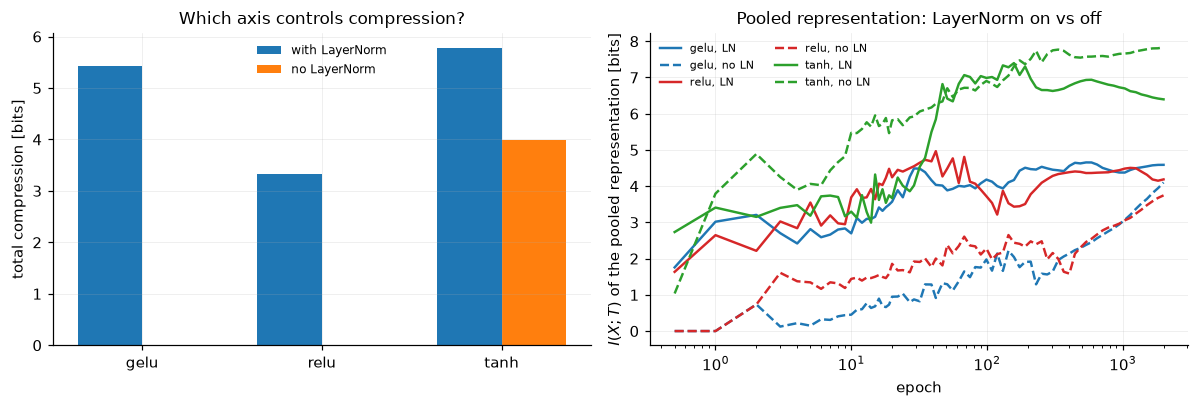

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))

ax = axes[0]
idx = np.arange(len(ACTS)); w = 0.36
ax.bar(idx - w/2, [comp[(a, True)].sum() for a in ACTS], width=w,
       label="with LayerNorm", color="#1f77b4")
ax.bar(idx + w/2, [comp[(a, False)].sum() for a in ACTS], width=w,
       label="no LayerNorm", color="#ff7f0e")
ax.set_xticks(idx); ax.set_xticklabels(ACTS)
ax.set_ylabel("total compression [bits]")
ax.set_title("Which axis controls compression?"); ax.legend()

ax = axes[1]
for a in ACTS:
    for ln, style in [(True, "-"), (False, "--")]:
        ixt = planes[(a, ln)][0]
        ax.plot(np.maximum(logs[(a, ln)]["epochs"], 0.5), ixt[:, -3], color=colors[a],
                ls=style, label=f"{a}, {'LN' if ln else 'no LN'}")
ax.set_xscale("log"); ax.set_xlabel("epoch")
ax.set_ylabel(r"$I(X;T)$ of the pooled representation [bits]")
ax.set_title("Pooled representation: LayerNorm on vs off"); ax.legend(ncol=2, fontsize=7)

fig.tight_layout(); save(fig, "figT3_ln_vs_activation"); plt.show()

## 4.1 Where inside the block does it happen?

LayerNorm is what *causes* the compression, but that does not tell us where it *shows up*.
The pre-norm block applies $\mathrm{LN}_2$ to the **input of the feed-forward sub-layer**, so
one place to look is the FFN hidden activations: their input scale is capped even as their
weights grow.

In [10]:
names = logs[("gelu", True)]["layer_names"]
print("compression per tracked representation [bits], WITH LayerNorm")
print(f"{'representation':16s} " + " ".join(f"{a:>8s}" for a in ACTS))
print("-" * 44)
for j, n in enumerate(names):
    print(f"{n:16s} " + " ".join(f"{comp[(a, True)][j]:>8.2f}" for a in ACTS))

ff_idx = [j for j, n in enumerate(names) if " ff" in n]
other_idx = [j for j, n in enumerate(names) if "attn" in n or "resid" in n or n == "pooled"]
print()
print(f"{'':8s} {'feed-forward layers':>21s} {'attention/residual/pooled':>27s}")
print("-" * 58)
for a in ACTS:
    print(f"{a:8s} {comp[(a, True)][ff_idx].sum():>16.2f} bits "
          f"{comp[(a, True)][other_idx].sum():>22.2f} bits")

compression per tracked representation [bits], WITH LayerNorm
representation       gelu     relu     tanh
--------------------------------------------
embed                0.38     0.84     0.76
B1 attn              0.01     0.29     0.17
B1 ff                2.28     0.21     0.27
B1 resid             0.00     0.02     0.16
B2 attn              0.01     0.00     0.03
B2 ff                1.85     0.13     0.57
B2 resid             0.22     0.28     0.22
pooled               0.07     0.78     1.00
head1                0.26     0.21     2.03
out                  0.35     0.57     0.57

           feed-forward layers   attention/residual/pooled
----------------------------------------------------------
gelu                 4.14 bits                   0.30 bits
relu                 0.34 bits                   1.37 bits
tanh                 0.84 bits                   1.57 bits


---

# 5. Reading the result

**Every part of the prediction holds, and the cleanest number is the simplest one:**

| activation | no LayerNorm | with LayerNorm |
|---|---|---|
| GELU | **0.00 bits** | **5.43 bits** |
| ReLU | **0.00 bits** | **3.32 bits** |
| tanh (control) | 4.00 bits | 5.78 bits |

A transformer whose only nonlinearity is ReLU-family compresses **exactly nothing** — until
a LayerNorm is added, at which point it compresses about half as much as the tanh MLP of
notebook 1. And tanh compresses with or without LayerNorm, because it supplies its own
bound: the paper's own mechanism, showing through the transformer exactly where it should.

So the two axes are not competitors. They are two routes to the same property, and
LayerNorm is the route the paper never examined.

## Two findings that sharpen the mechanism

**1. For GELU, the compression appears in the *feed-forward* activations — 4.14 of its 5.43
bits — not in attention or the residual stream (0.30 bits).** LayerNorm is what causes it
but not where it shows up: $\mathrm{LN}_2$ sits on the **input** to the feed-forward
sub-layer, so it caps the scale of what the FFN sees while the FFN's own weights keep
growing. The cap is applied in one place and its effect is measured in another. (For tanh
the compression sits instead in the tanh head layer, 2.03 bits — again exactly where the
bounded map is.)

**2. Removing LayerNorm makes attention saturate far *harder* — and compress *less*.**
Without normalisation, GELU's attention entropy collapses from $3.56$ to $0.41$ bits, nearly
one-hot, versus $3.50 \to 2.60$ with LayerNorm on. Yet the no-LN run compresses $0.00$ bits.
The other diagnostic explains it: without LayerNorm the residual-stream norm explodes from
$2.1$ to $77$ (ReLU: $94$), while with LayerNorm it stays near $12$–$14$. **Unbounded
spreading raises entropy faster than sharpened attention lowers it.**

## The refined mechanism

> What produces apparent compression is **not "saturation" loosely construed**. It is a
> representation whose **scale stops growing while the weights keep growing**.

A tanh unit has that property because of its asymptotes. LayerNorm has it by construction.
Softmax attention on its own does **not** — even when it sharpens all the way to one-hot —
because the value vectors it averages can still grow without bound. That is a genuine
refinement: of the two bounded operations we set out to test, only one of them actually
produces the effect, and the diagnostics say why.

## Why this matters

Modern architectures are routinely described as "ReLU-family" and therefore, on a naive
reading of Saxe et al., exempt from the compression story. But **LayerNorm is present in
essentially every transformer**, and it imposes precisely the fixed ceiling that drives the
effect. Any information-plane analysis of a normalised architecture has to account for the
normalisation before attributing a trajectory to learning.

And the paper's deeper point applies here unchanged: none of these numbers is a property of
the transformer alone. They are properties of the transformer *and* a binning convention.
What we have shown is a **contrast measured under a fixed convention** — which is the honest
form such a claim can take.

## Caveats

* One seed per configuration, one architecture, one small synthetic task. This is an
  exploratory extension, not a systematic study.
* Pooling over positions discards information; a different tracked representation could give
  different magnitudes. The LayerNorm/activation *contrast* is measured under identical
  pooling, so the comparison itself is fair.
* The binning range is set per run from observed extremes (the appendix-C protocol for
  unbounded activations), which means the LN and no-LN runs are binned over different
  ranges. That is the same arbitrariness the whole paper is about, and it applies to this
  extension too.

---

## Where to go deeper

[`../notebooks/07_transformer.ipynb`](../notebooks/07_transformer.ipynb) is the project's
earlier, longer study of the same question, built on the `ibdl` library: it tracks the same
six configurations with more diagnostics and reports the effect in terms of main effects
rather than the table above. It is an independent run, so individual magnitudes differ; the
mechanism and the conclusion are the same.

For the reproduction this extension builds on, see
[`1_information_bottleneck.ipynb`](1_information_bottleneck.ipynb), and for the rest of the
research record the map at the end of that notebook.